In [1]:
import pca_utils as pca_utils
import pandas as pd

In [101]:
# In the source dataset, 0 represents an unrecorded measurement.
# Reads the CSV file and sets 0 values to NULL
df = pd.read_csv(
    "Allsharkteeth.csv", 
    skipinitialspace = True,
    na_values = "0"
)
data_frame = df.copy(deep=True)
#data_frame

In [102]:
# Counts how many NULL values in each attribute
count = data_frame.isnull().sum()
count

Locality       0
Specimen #     0
Taxon          0
Position       0
BCW            0
CH             2
DCL            2
IDCL           2
IMCL           2
LCH           68
LCW           66
MCL            2
PCH            2
PCW            2
RH            13
RW            12
TH             0
DS             2
CDS           67
RA            22
dtype: int64

In [103]:
# I'm going to impute the overall median value for all other attributes.

cols_to_impute = [ 
    'RH', 'RW', 'RA', 'CH', 'DCL', 'IDCL', 'IMCL', 'MCL', 'PCH', 'PCW', 'DS'
]

overall_medians = data_frame[cols_to_impute].median()
data_frame[cols_to_impute] = data_frame[cols_to_impute].fillna(overall_medians)

In [104]:
# There are three columns dedicated to cusplet measurments:
#   LCH, LCW, CDS
# Not all species have cusplets. I am going to set these values to 0 to later compare the resulting PCA 
# to a seperate PCA analysis dropping cusplet measurments.

cusp_cols = ['LCH', 'LCW', 'CDS']
data_frame[cusp_cols] = data_frame[cusp_cols].fillna(0)

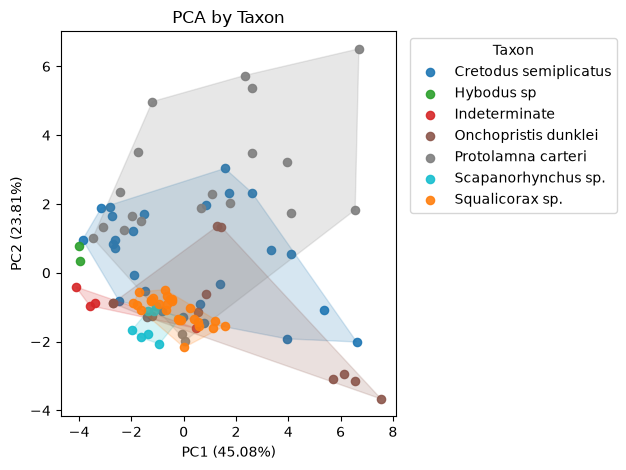

In [105]:
scaled_data = pca_utils.get_numeric_data(data_frame)
pca, var = pca_utils.plot_pca(data_frame, scaled_data)

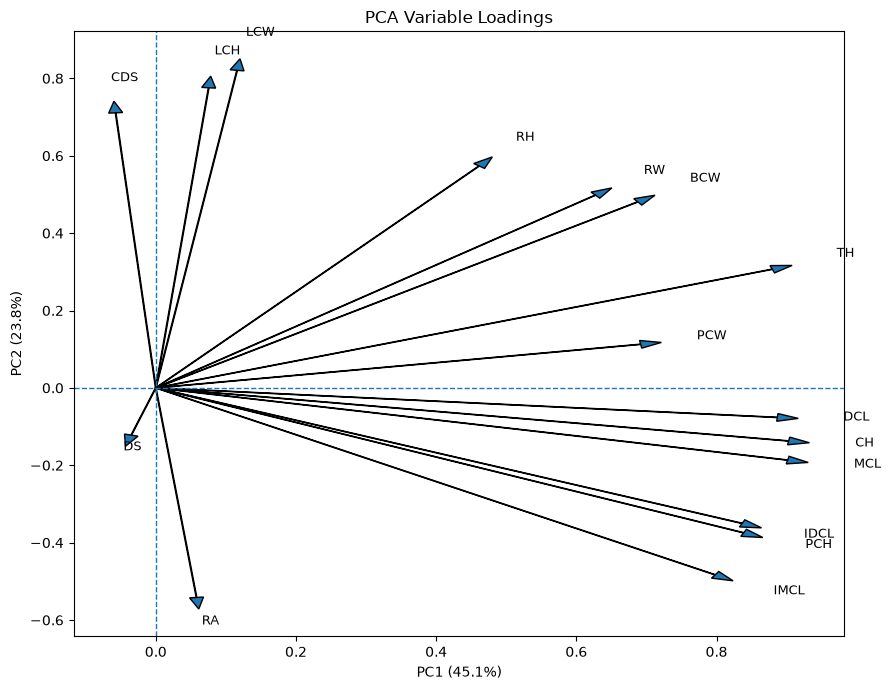

In [106]:
pca_utils.get_loadings(pca, scaled_data, var)

In [107]:
pca_utils.get_weights(pca, scaled_data)

Top contributors to PC1:
           PC1       PC2
CH    0.345461 -0.072234
MCL   0.344818 -0.098249
DCL   0.339559 -0.040213
TH    0.336306  0.161340
PCH   0.320820 -0.197159
IDCL  0.320138 -0.184422
IMCL  0.305119 -0.254198
PCW   0.267224  0.059875
BCW   0.263837  0.253832
RW    0.241048  0.263469 

Top contributors to PC2:
           PC1       PC2
LCW   0.044512  0.433528
LCH   0.029029  0.410632
CDS  -0.022111  0.377636
RH    0.177861  0.304299
RA    0.022725 -0.291312
RW    0.241048  0.263469
IMCL  0.305119 -0.254198
BCW   0.263837  0.253832
PCH   0.320820 -0.197159
IDCL  0.320138 -0.184422


In [108]:
# Now creating a new dataset that drops the cusplet measurements and see how the PCA model changes.

no_cusplets = data_frame.copy(deep=True)
no_cusplets = no_cusplets.drop(columns=cusp_cols)

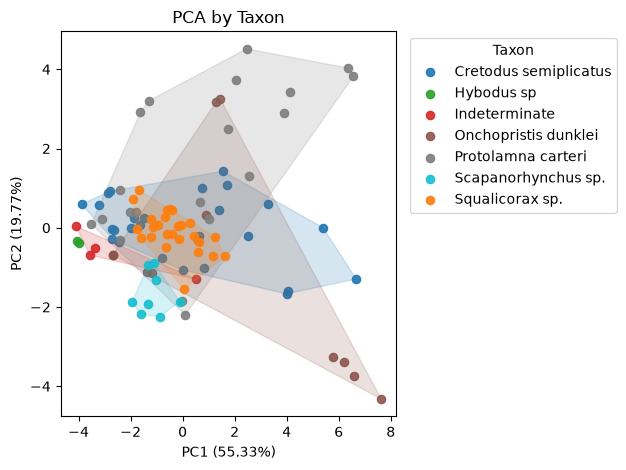

In [109]:
scaled_data = pca_utils.get_numeric_data(no_cusplets)
pca, var = pca_utils.plot_pca(no_cusplets, scaled_data)

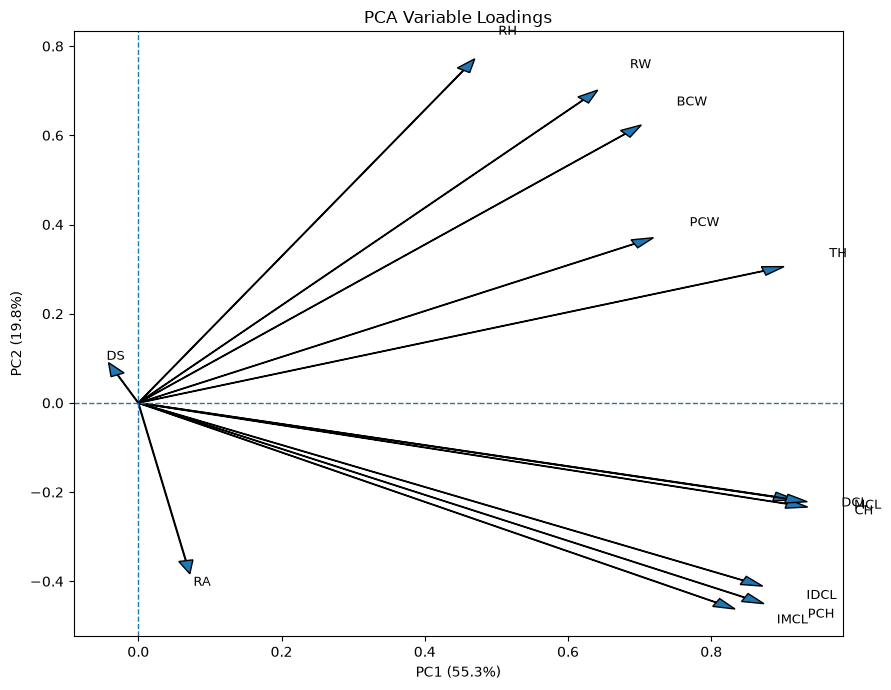

In [110]:
pca_utils.get_loadings(pca, scaled_data, var)

In [111]:
pca_utils.get_weights(pca, scaled_data)

Top contributors to PC1:
           PC1       PC2
CH    0.346701 -0.144951
MCL   0.346468 -0.137533
DCL   0.340302 -0.134662
TH    0.334440  0.189623
PCH   0.324021 -0.279326
IDCL  0.323395 -0.254940
IMCL  0.309041 -0.286749
PCW   0.266831  0.229863
BCW   0.260555  0.386735
RW    0.237956  0.435259 

Top contributors to PC2:
           PC1       PC2
RH    0.174247  0.478739
RW    0.237956  0.435259
BCW   0.260555  0.386735
IMCL  0.309041 -0.286749
PCH   0.324021 -0.279326
IDCL  0.323395 -0.254940
RA    0.026678 -0.237822
PCW   0.266831  0.229863
TH    0.334440  0.189623
CH    0.346701 -0.144951


In [112]:
# Going to one hot encode Taxon that have cusplets and those that do not have cusplets to see if there is a difference in the PCA model.

cuspletless_taxa = [
    "Squalicorax sp.",
    "Scapanorhynchus sp.",
    "Onchopristis dunklei",
                     ]

encoded_cusplets = data_frame.copy(deep=True)
encoded_cusplets = encoded_cusplets.drop(columns=cusp_cols)
encoded_cusplets["Cusplets"] = encoded_cusplets["Taxon"].apply(lambda x: 0 if x in cuspletless_taxa else 1)


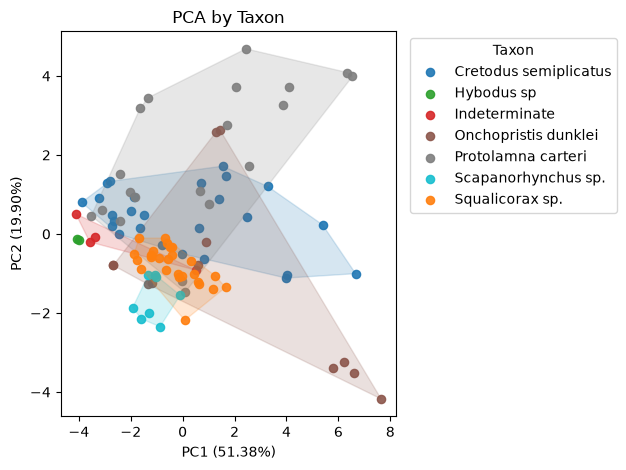

In [113]:
scaled_data = pca_utils.get_numeric_data(encoded_cusplets)
pca, var = pca_utils.plot_pca(encoded_cusplets, scaled_data)

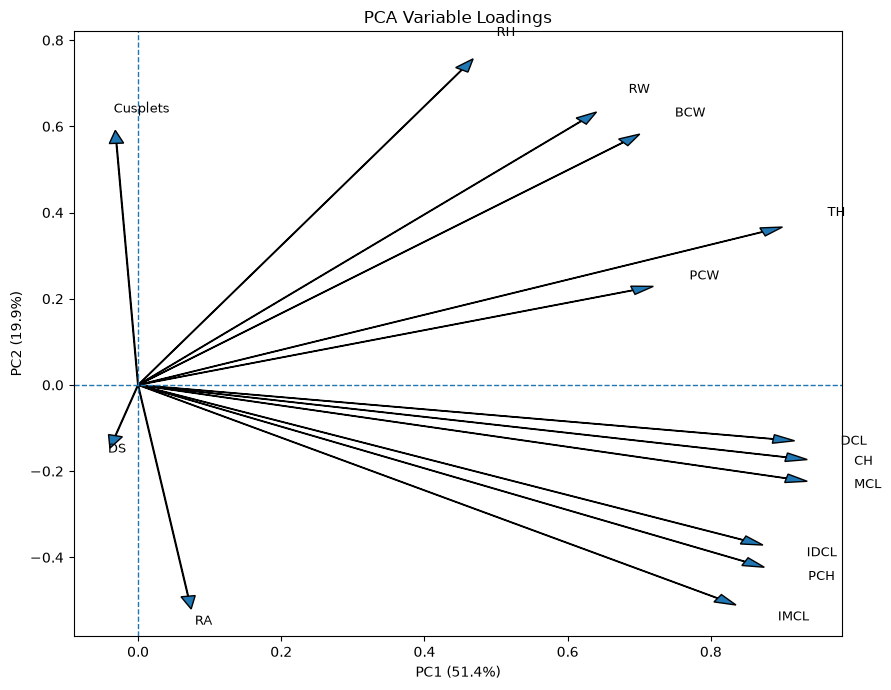

In [114]:
pca_utils.get_loadings(pca, scaled_data, var)

In [115]:
pca_utils.get_weights(pca, scaled_data)

Top contributors to PC1:
           PC1       PC2
CH    0.346709 -0.103236
MCL   0.346684 -0.133302
DCL   0.340134 -0.077242
TH    0.333836  0.218418
PCH   0.324431 -0.252164
IDCL  0.323722 -0.221458
IMCL  0.309765 -0.304366
PCW   0.266954  0.136368
BCW   0.259908  0.346984
RW    0.237498  0.377519 

Top contributors to PC2:
               PC1       PC2
RH        0.173578  0.451068
RW        0.237498  0.377519
Cusplets -0.011780  0.352086
BCW       0.259908  0.346984
RA        0.027507 -0.309904
IMCL      0.309765 -0.304366
PCH       0.324431 -0.252164
IDCL      0.323722 -0.221458
TH        0.333836  0.218418
PCW       0.266954  0.136368


In [116]:
taxon_data = df.copy(deep=True)

taxon_data = taxon_data.drop(columns=cusp_cols)
taxon_data["Cusplets"] = taxon_data["Taxon"].apply(lambda x: 0 if x in cuspletless_taxa else 1)

# Missing data imputed with taxa median
taxon_medians = taxon_data.groupby('Taxon')[cols_to_impute].transform('median')
taxon_data[cols_to_impute] = taxon_data[cols_to_impute].fillna(taxon_medians)

# For taxon missing all measurments impute with overall median.
taxon_data[cols_to_impute] = taxon_data[cols_to_impute].fillna(overall_medians)

# Sanity check
assert taxon_data[cols_to_impute].isna().sum().sum() == 0

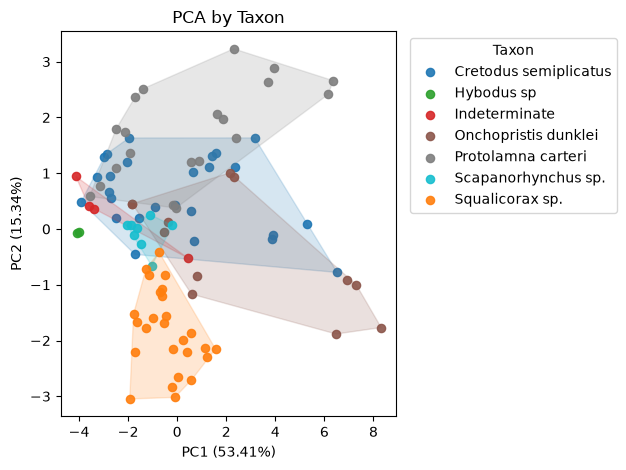

In [117]:
scaled_data = pca_utils.get_numeric_data(taxon_data)
pca, var = pca_utils.plot_pca(taxon_data, scaled_data)

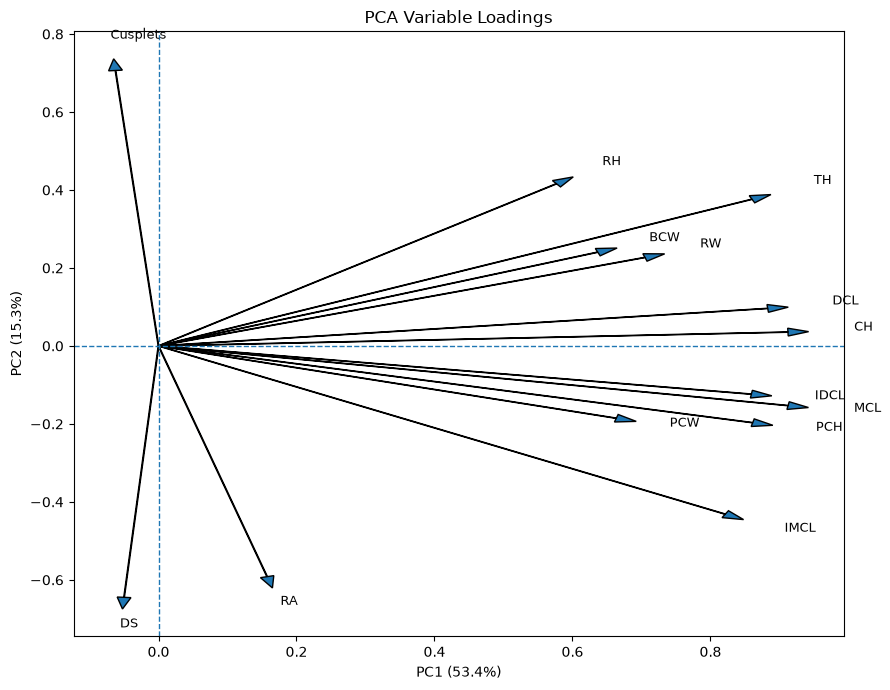

In [118]:
pca_utils.get_loadings(pca, scaled_data, var)

In [119]:
pca_utils.get_weights(pca, scaled_data)

Top contributors to PC1:
           PC1       PC2
CH    0.342843  0.024890
MCL   0.342763 -0.107244
DCL   0.332114  0.067502
PCH   0.323989 -0.138170
IDCL  0.323459 -0.086851
TH    0.322976  0.263536
IMCL  0.308535 -0.302376
RW    0.266921  0.160298
PCW   0.251929 -0.131361
BCW   0.241842  0.170442 

Top contributors to PC2:
               PC1       PC2
Cusplets -0.023647  0.499865
DS       -0.019001 -0.458010
RA        0.060082 -0.421383
IMCL      0.308535 -0.302376
RH        0.218718  0.294284
TH        0.322976  0.263536
BCW       0.241842  0.170442
RW        0.266921  0.160298
PCH       0.323989 -0.138170
PCW       0.251929 -0.131361


In [120]:
# Only performing PCA on Lamniformes.

lamniformes = [
    "Squalicorax sp.",
    "Scapanorhynchus sp.",
    "Protolamna carteri",
    "Cretodus semiplicatus"
                     ]

lamniforme_data = encoded_cusplets.copy(deep=True)

lamniforme_data = lamniforme_data[lamniforme_data["Taxon"].isin(lamniformes)]

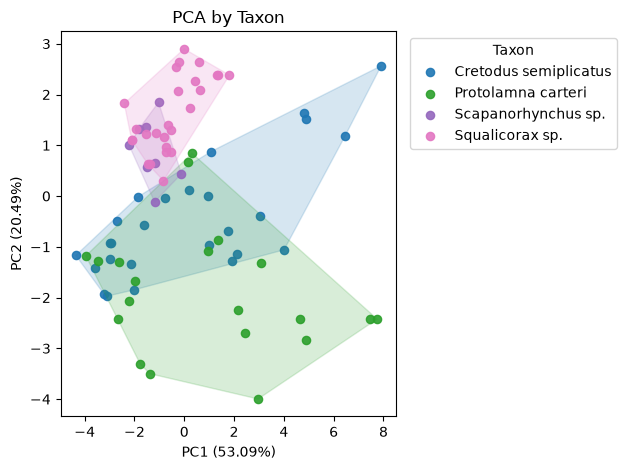

In [121]:
scaled_data = pca_utils.get_numeric_data(lamniforme_data)
pca, var = pca_utils.plot_pca(lamniforme_data, scaled_data)

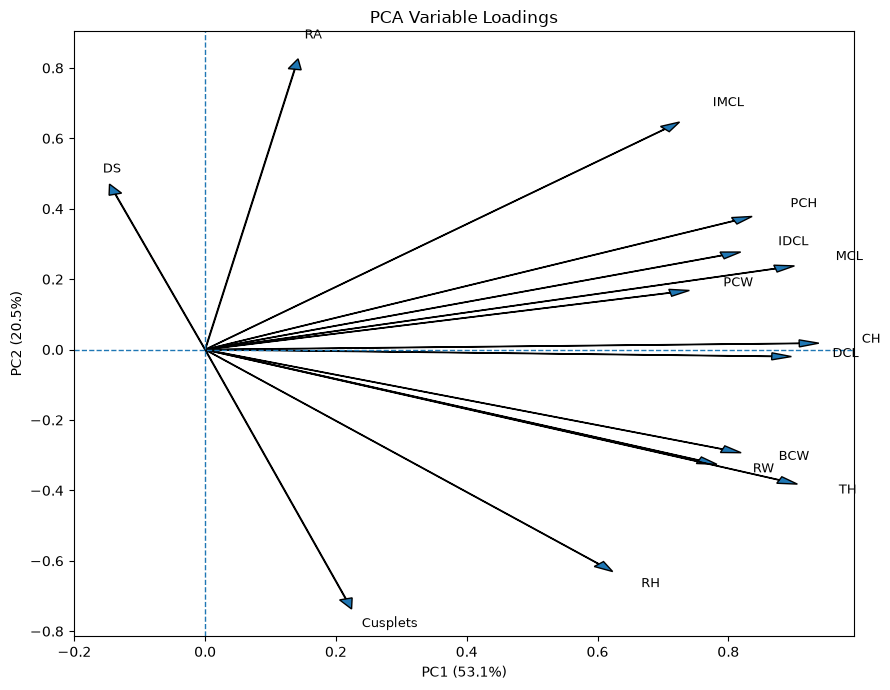

In [122]:
pca_utils.get_loadings(pca, scaled_data, var)

In [123]:
pca_utils.get_weights(pca, scaled_data)

Top contributors to PC1:
           PC1       PC2
CH    0.342081  0.010712
TH    0.330120 -0.224186
MCL   0.328481  0.139516
DCL   0.326787 -0.011605
PCH   0.304896  0.221931
BCW   0.298764 -0.171872
IDCL  0.298526  0.162644
RW    0.285303 -0.191183
PCW   0.269922  0.098591
IMCL  0.264430  0.379273 

Top contributors to PC2:
               PC1       PC2
RA        0.051802  0.484608
Cusplets  0.081630 -0.432312
IMCL      0.264430  0.379273
RH        0.227169 -0.369923
DS       -0.053293  0.275824
TH        0.330120 -0.224186
PCH       0.304896  0.221931
RW        0.285303 -0.191183
BCW       0.298764 -0.171872
IDCL      0.298526  0.162644


In [124]:
# Trying the same PCA analysis on Lamniformes but with cusplet measurements dropped.
# Use this one

nc_lamniforme_data = no_cusplets.copy(deep=True)

nc_lamniforme_data = nc_lamniforme_data[nc_lamniforme_data["Taxon"].isin(lamniformes)]

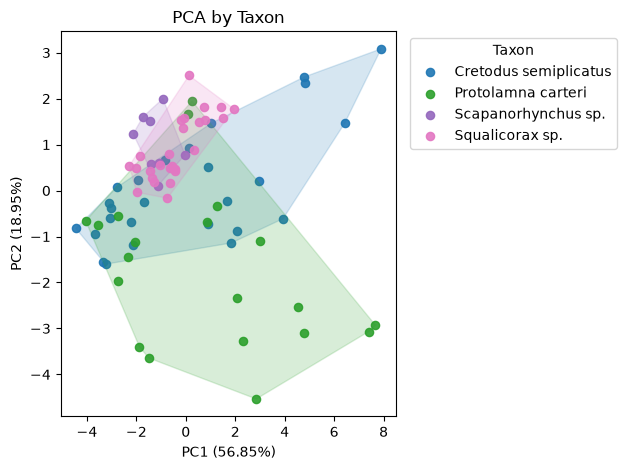

In [125]:
scaled_data = pca_utils.get_numeric_data(nc_lamniforme_data)
pca, var = pca_utils.plot_pca(nc_lamniforme_data, scaled_data)

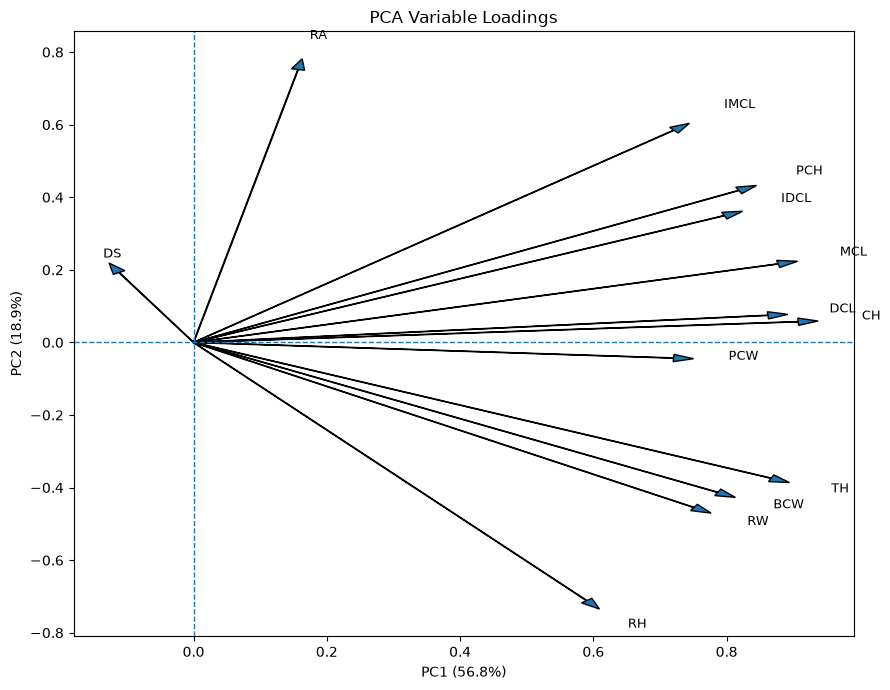

In [126]:
pca_utils.get_loadings(pca, scaled_data, var)

In [127]:
pca_utils.get_weights(pca, scaled_data)

Top contributors to PC1:
           PC1       PC2
CH    0.342650  0.037330
MCL   0.331365  0.141558
TH    0.326943 -0.244504
DCL   0.326023  0.048929
PCH   0.308857  0.273847
IDCL  0.301237  0.228881
BCW   0.297258 -0.270414
RW    0.283898 -0.297806
PCW   0.274297 -0.028401
IMCL  0.272012  0.382258 

Top contributors to PC2:
           PC1       PC2
RA    0.059581  0.494776
RH    0.222674 -0.465082
IMCL  0.272012  0.382258
RW    0.283898 -0.297806
PCH   0.308857  0.273847
BCW   0.297258 -0.270414
TH    0.326943 -0.244504
IDCL  0.301237  0.228881
MCL   0.331365  0.141558
DS   -0.046336  0.138451


In [128]:
only_sharks = no_cusplets.copy(deep=True)
only_sharks = only_sharks[only_sharks["Taxon"] != "Onchopristis dunklei"]

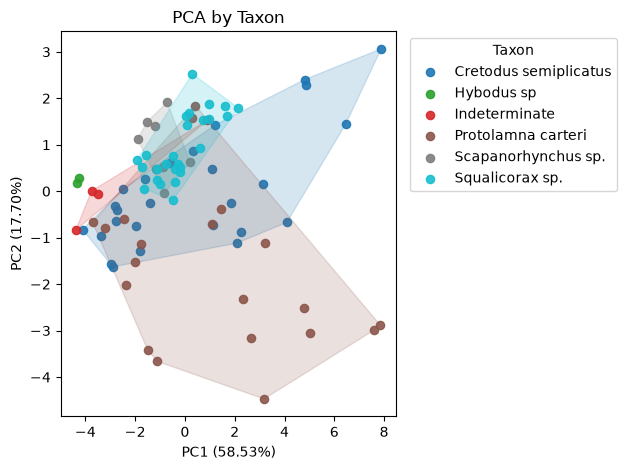

In [129]:
scaled_data = pca_utils.get_numeric_data(only_sharks)
pca, var = pca_utils.plot_pca(only_sharks, scaled_data)

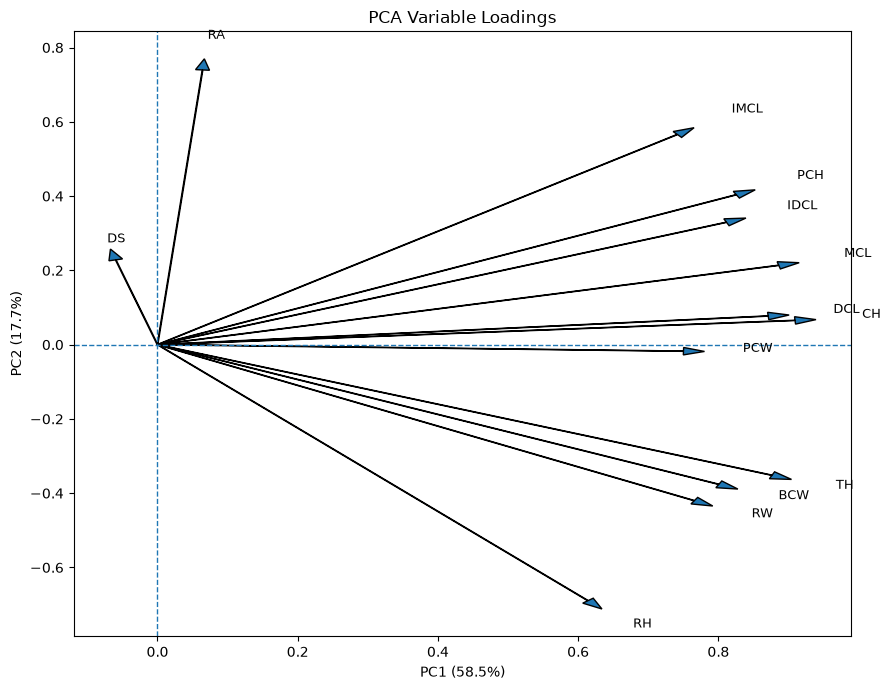

In [130]:
pca_utils.get_loadings(pca, scaled_data, var)

In [131]:
pca_utils.get_weights(pca, scaled_data)

Top contributors to PC1:
           PC1       PC2
CH    0.338517  0.044185
MCL   0.329872  0.144599
TH    0.325920 -0.237854
DCL   0.324704  0.052292
PCH   0.307265  0.273217
IDCL  0.302499  0.223376
BCW   0.298353 -0.254878
RW    0.285440 -0.284798
PCW   0.281203 -0.012006
IMCL  0.275832  0.382836 

Top contributors to PC2:
           PC1       PC2
RA    0.024089  0.504394
RH    0.228481 -0.466527
IMCL  0.275832  0.382836
RW    0.285440 -0.284798
PCH   0.307265  0.273217
BCW   0.298353 -0.254878
TH    0.325920 -0.237854
IDCL  0.302499  0.223376
DS   -0.024188  0.168654
MCL   0.329872  0.144599


In [132]:
thrashers = [
    "Scapanorhynchus sp.",
    "Protolamna carteri",
    "Cretodus semiplicatus"
                     ]

thrashing_sharks = no_cusplets.copy(deep=True)
thrashing_sharks = thrashing_sharks[thrashing_sharks["Taxon"].isin(thrashers)]

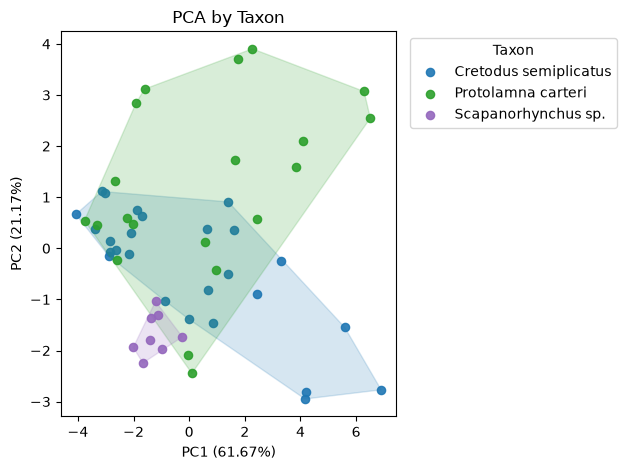

In [133]:
scaled_data = pca_utils.get_numeric_data(thrashing_sharks)
pca, var = pca_utils.plot_pca(thrashing_sharks, scaled_data)

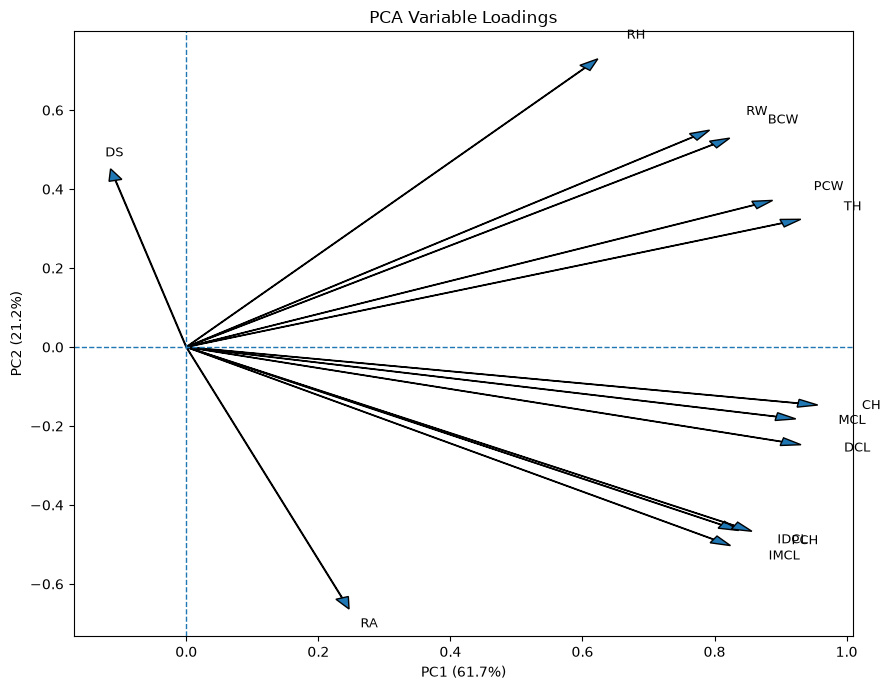

In [134]:
pca_utils.get_loadings(pca, scaled_data, var)

In [135]:
pca_utils.get_weights(pca, scaled_data)

Top contributors to PC1:
           PC1       PC2
CH    0.334594 -0.087712
DCL   0.325736 -0.147749
TH    0.325623  0.193278
MCL   0.322962 -0.108679
PCW   0.310702  0.221845
PCH   0.299722 -0.278701
IDCL  0.292691 -0.277495
IMCL  0.288364 -0.300322
BCW   0.287976  0.316045
RW    0.277280  0.328084 

Top contributors to PC2:
           PC1       PC2
RH    0.218072  0.435947
RA    0.086248 -0.396237
RW    0.277280  0.328084
BCW   0.287976  0.316045
IMCL  0.288364 -0.300322
PCH   0.299722 -0.278701
IDCL  0.292691 -0.277495
DS   -0.040114  0.269530
PCW   0.310702  0.221845
TH    0.325623  0.193278


In [136]:
ESS = no_cusplets.copy(deep=True)
ESS = ESS[ESS["Locality"] == "Emergency Spillway site"]

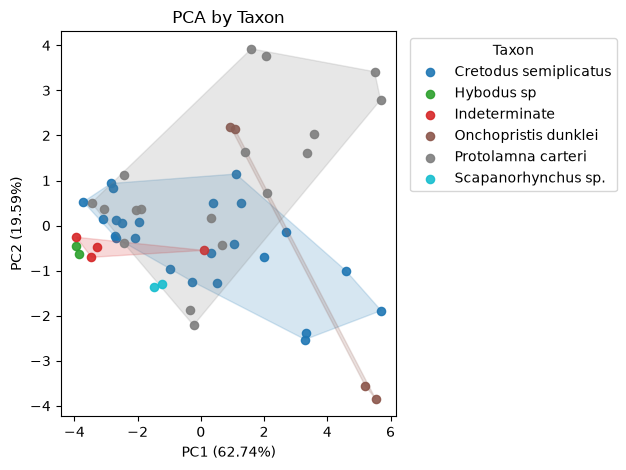

In [137]:
scaled_data = pca_utils.get_numeric_data(ESS)
pca, var = pca_utils.plot_pca(ESS, scaled_data)

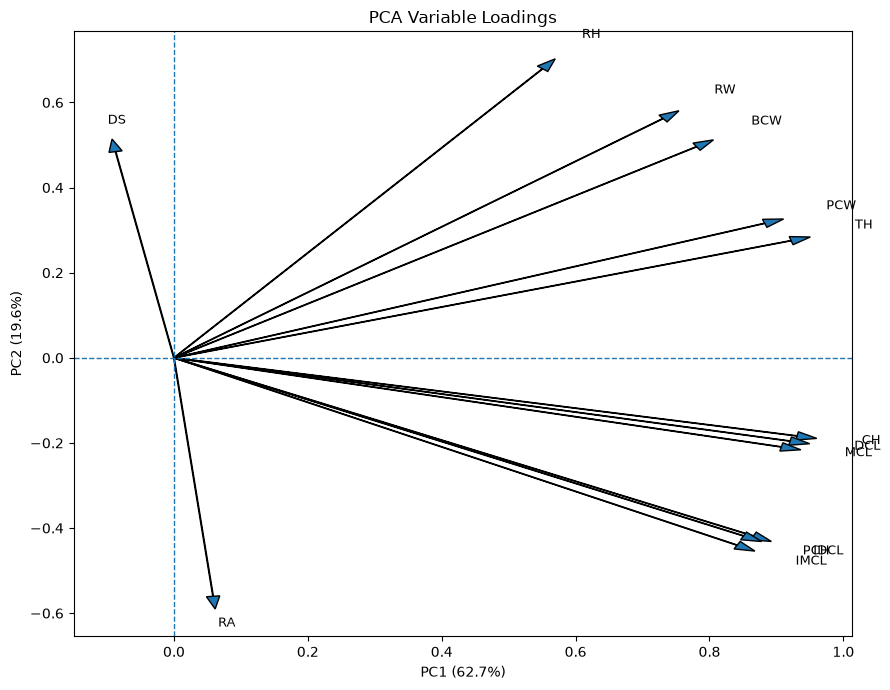

In [138]:
pca_utils.get_loadings(pca, scaled_data, var)

In [139]:
pca_utils.get_weights(pca, scaled_data)

Top contributors to PC1:
           PC1       PC2
CH    0.333114 -0.117534
TH    0.329783  0.176264
DCL   0.329450 -0.125295
MCL   0.324881 -0.134159
PCW   0.315921  0.202518
IDCL  0.309602 -0.267919
PCH   0.304520 -0.267999
IMCL  0.301047 -0.281910
BCW   0.279587  0.317991
RW    0.261691  0.360425 

Top contributors to PC2:
           PC1       PC2
RH    0.197575  0.436160
RA    0.021367 -0.366380
RW    0.261691  0.360425
DS   -0.032080  0.319115
BCW   0.279587  0.317991
IMCL  0.301047 -0.281910
PCH   0.304520 -0.267999
IDCL  0.309602 -0.267919
PCW   0.315921  0.202518
TH    0.329783  0.176264


In [140]:
DLAL = no_cusplets.copy(deep=True)
DLAL = DLAL[DLAL["Locality"] == "Dallas Love Airport Locality"]

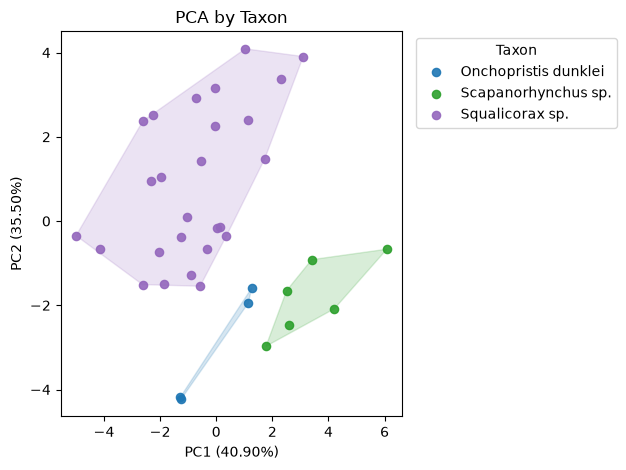

In [141]:
scaled_data = pca_utils.get_numeric_data(DLAL)
pca, var = pca_utils.plot_pca(DLAL, scaled_data)

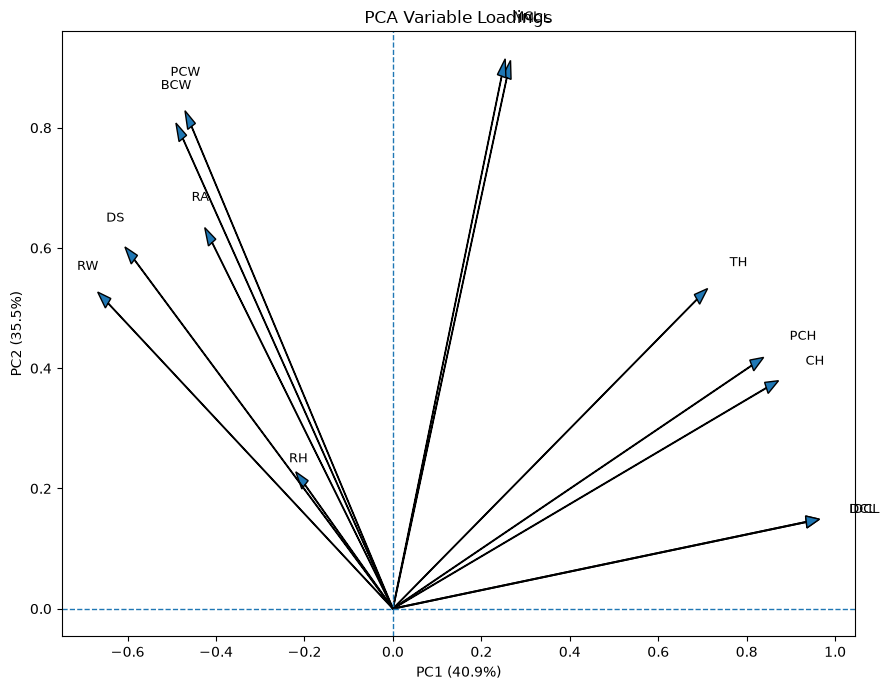

In [142]:
pca_utils.get_loadings(pca, scaled_data, var)

In [143]:
pca_utils.get_weights(pca, scaled_data)

Top contributors to PC1:
           PC1       PC2
DCL   0.412384  0.068318
IDCL  0.412384  0.068318
CH    0.372879  0.174060
PCH   0.358468  0.191860
TH    0.304280  0.244423
RW   -0.285474  0.241746
DS   -0.259126  0.276184
BCW  -0.209822  0.370788
PCW  -0.201060  0.380201
RA   -0.181974  0.290961 

Top contributors to PC2:
           PC1       PC2
MCL   0.108573  0.419812
IMCL  0.113722  0.418619
PCW  -0.201060  0.380201
BCW  -0.209822  0.370788
RA   -0.181974  0.290961
DS   -0.259126  0.276184
TH    0.304280  0.244423
RW   -0.285474  0.241746
PCH   0.358468  0.191860
CH    0.372879  0.174060
